In [20]:
import gfapy
from dimod import make_quadratic, BinaryPolynomial, BINARY
import sympy as sp
from math import log2, ceil
import networkx as nx
from matplotlib import pyplot as plt
import numpy as np
import re
from itertools import product
import time

In [21]:
N = 7
logN = ceil(log2(N+1))

t_max = 9
var = sp.symbols(f'a_(0:{t_max})_(0:{logN})')
var_str = [str(v) for v in var]
var_arr = np.array(var)
var_arr = var_arr.reshape((t_max, logN))
lambda_g = 10
lambda_w = 1

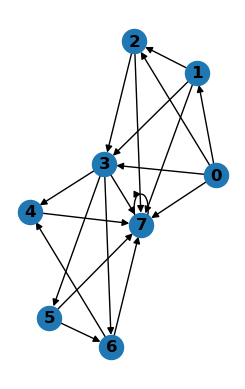

In [22]:
g = nx.DiGraph()
g.add_nodes_from([
    (0, {"weight": 1}),
    (1, {"weight": 1}),
    (2, {"weight": 1}),
    (3, {"weight": 1}),
    (4, {"weight": 1}),
    (5, {"weight": 1}),
    (6, {"weight": 1}),
    (7),
])
g.add_edges_from([
    (0, 1),
    (0, 2),
    (0, 3),
    (0, 7),
    (1, 2),
    (1, 3),
    (1, 7),
    (2, 3),
    (2, 7),
    (3, 4),
    (3, 5),
    (3, 6),
    (3, 7),
    (4, 7),
    (5, 6),
    (5, 7),
    (6, 4),
    (6, 7),
    (7, 7),
])
subax1 = plt.subplot(121)
nx.draw_kamada_kawai(g, with_labels=True, font_weight='bold')

relabel_g = nx.convert_node_labels_to_integers(g)


In [3]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into an oriented graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for segment_line in gfa.segments:
        graph.add_node(f'{segment_line.name}_+', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
        graph.add_node(f'{segment_line.name}_-', sequence=segment_line.sequence, weight=segment_line.SC, start=segment_line.st)
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        graph.add_edges_from([
            (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
        ])
        v1.invert()
        v2.invert()
        graph.add_edges_from([
            (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
        ])
    graph.add_node('end', weight=int(0))
    for node in graph.nodes:
        graph.add_edges_from([
            (node, 'end')
        ])
    return graph

In [4]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

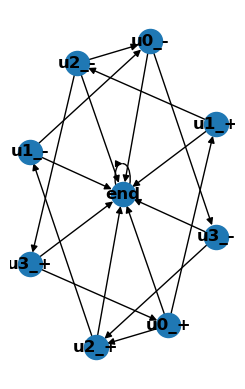

In [5]:
g = oriented_graph_from_file('../../data/test.gfa')
# g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k501.utg.final.gfa')
# g = normalise_node_weights(g, 100)

relabel_g = nx.convert_node_labels_to_integers(g)


N = len(list(relabel_g.nodes)) - 1
t_max = int(sum(relabel_g.nodes[i]["weight"] for i in range(N)) / 2)
logN = ceil(log2(N+1))

var = sp.symbols(f'a_(0:{t_max})_(0:{logN})')
var_str = [str(v) for v in var]
var_arr = np.array(var, dtype=sp.Expr)
var_arr = var_arr.reshape((t_max, logN))


lambda_g = 10
lambda_w = 1


subax1 = plt.subplot(121)
nx.draw_kamada_kawai(g, with_labels=True, font_weight='bold')

In [23]:
def int_to_bin_arr(n):
    bin_list = [int(x) for x in list(format(n, f'0{logN}b'))]
    bin_list.reverse()
    return np.array(bin_list)

In [24]:
all_bin = [int_to_bin_arr(i) for i in range(N+1)]
all_pairs = set(product(range(N+1), range(N+1)))
# non_edges = all_pairs - set(relabel_g.edges)
non_edges = set(relabel_g.edges)
non_edges_bin = [(all_bin[non_edge[0]], all_bin[non_edge[1]]) for non_edge in non_edges]
non_edges_bin_arr = np.array([[neb[0], neb[1]] for neb in non_edges_bin])

In [25]:
def indicator(bin_arr, var_arr):
    return np.prod(1 - var_arr - bin_arr + 2 * var_arr * bin_arr)

In [26]:
def single_time_contribution(t):
    return lambda_g * np.sum(
        np.apply_along_axis(indicator, 1, non_edges_bin_arr[:, 0, :], var_arr[t, :]) 
        * np.apply_along_axis(indicator, 1, non_edges_bin_arr[:, 1, :], var_arr[t + 1, :])
    )

In [27]:
def contribution_from_binary(var_arr_row, binary_arr_col):
    return np.apply_along_axis(indicator, 1, non_edges_bin_arr[:, binary_arr_col, :], var_arr_row) 

In [29]:
indicator(non_edges_bin_arr[0, 0, :], var_arr[0, :])

a_0_0*a_0_1*(1 - a_0_2)

In [30]:
poly = sp.Add()
s = time.time()
first_col_cont = np.apply_along_axis(contribution_from_binary, 1, var_arr, 0)
first_col_cont = np.delete(first_col_cont, -1, 0)
second_col_cont = np.apply_along_axis(contribution_from_binary, 1, var_arr, 1)
second_col_cont= np.delete(second_col_cont, 0, 0)
e = time.time()
print(e - s)

0.04857683181762695


In [31]:
s = time.time()
all_cont = first_col_cont * second_col_cont
e = time.time()
print(e - s)

0.02067279815673828


In [32]:
s = time.time()
# poly += lambda_g * np.sum(all_cont)
poly -= lambda_g * np.sum(all_cont)
e = time.time()
print(e - s)

0.14599323272705078


In [33]:
# for t in range(t_max-1):
# for t in range(1):
#     s = time.time()
#     poly += single_time_contribution(t)
#     e = time.time()
#     print(e - s)

In [34]:
s = time.time()
for i in range(N):
    i_bin = int_to_bin_arr(i)
    poly += lambda_w * np.sum(np.apply_along_axis(
        indicator,
        1,
        var_arr,
        i_bin
    ) ** 2)
e = time.time()
print(e - s)

0.022563695907592773


In [35]:
poly = sp.expand(poly)
poly = poly.subs([(v ** 2, v) for v in var])

In [36]:
poly_coeffs = poly.as_coefficients_dict()
offset = poly_coeffs.pop(1, None)

In [37]:
binary_poly_dict = {}
for key in poly_coeffs.keys():
    matches = re.findall(
        r'(a_\d_\d)',
        str(key)
    )
    indexes = tuple([var_str.index(match) for match in matches])
    binary_poly_dict[indexes] = poly_coeffs[key]


In [38]:
# Improvement in number of vars only visible at large N : TN vs T (logN)**4. Graphs with ~65,000 nodes.
bqm = make_quadratic(binary_poly_dict, 5.0, BINARY)
print(f'Naive vars: {t_max * (N+1)}')
print(f'HUBO vars: {bqm.num_variables}')
print(bqm.variables)

Naive vars: 72
HUBO vars: 96
Variables([3, 4, '3*4', 9, 10, '9*10', 6, 7, '6*7', 16, 15, '16*15', 21, 22, '21*22', 18, 19, '18*19', 12, 13, '12*13', 24, 25, '24*25', 1, 5, '1*5', 26, 23, '26*23', 8, 11, '8*11', 17, 20, '17*20', '8*5', 14, '17*14', '11*14', '20*23', 0, 2, '0*2', '8*6*7', '18*20', '16*15*17', '4*5', '21*23', '9*10*11', '8*6', '20*18*19', '12*13*14', '12*14', '21*22*23', '9*11', '3*5', '17*15', '5*3*4', '13*14', '8*7', '10*11', '19*20', '16*17', '22*23', '8*5*4', '1*3*4', '8*11*7', '24*26', '17*14*15', '20*23*19', '1*5*3*4', '12*11*14', '17*20*18', '1*5*3', '24*26*23', '1*3', '26*24*25', '2*4', '26*23*24*25', '9*8*11', '8*5*3*4', '25*22', '17*20*19', '12*13*11*14', '13*11*14', '8*5*3', '17*14*13', '20*23*18', '17*20*18*19', '20*23*18*19', '16*12', '9*10*8*11', '21*26*23', '17*14*12*13', '10*8*11'])


TODO: think about using binary expressions I_t = (x_0 + 2*x_1 + 4*x_2 +...) at each time. Need to find a function that is positive for any pair (I_t, I_{t+1}) that is not a graph edge. 